# 00 · Setup and data preparation

Finds the dataset wherever it lives, turns Cuba's pixel ground truth into YOLO-format seed labels, measures how big a real red blood cell actually is, expands the label set with audited SAM pseudo-labels, and assembles the train/val split **by smear**.

Everything downstream depends on this notebook, and on nothing else. Run it once.

---

> **Where this sits.** `00 setup` → stage 1 candidates `01 YOLO` · `02 SAM` · `03 Moondream` → `04 seg shoot-out` → `05 crop dataset` → stage 2 candidates `06 InceptionV3` · `07 MaxViT-tiny` · `08 ResNet50` · `09 MobileNet+SVM` · `10 QSVM` → `11 cls shoot-out` → `12 Grad-CAM` → `13 external set` → `14 end-to-end` → `15 gap`. Every stage reads the previous one's artefacts from `runs_two_stage/`, so this notebook runs on its own — it does **not** need the others to be open.

### Bootstrap — environment, hardware profile, shared config

Identical in every notebook of this series. It detects where it is running
(**Colab/T4**, **IBEX/A100**, or local), turns on the right accelerations for that GPU, pins the
seed, and re-opens the shared `runs_two_stage/` folder so **any notebook can be run on its own** —
each stage reads the previous stage's artefacts from disk, not from memory.

**The A100 / T4 split is deliberate.** Only *throughput* knobs change with the GPU (batch size,
dataloader workers, AMP dtype, RAM caching, how many smears SAM pseudo-labels). *Capacity* knobs —
model size, image size, epochs — stay identical on both, so an A100 run and a T4 run remain
scientifically comparable. Every result file records the tier that produced it.

In [1]:
# ═════════════════════════════════════════════════════════════════════════════
#  SCD pipeline · shared bootstrap  (identical in every notebook of the series)
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart.

    On managed images (Kaggle / Colab / IBEX) pip usually lands in the per-user site
    directory. If that directory did not exist when python started, site.py never put it
    on sys.path -- so a fresh install stays invisible until the kernel is restarted.
    Re-adding the install targets by hand is what removes the "restart and run all" step.
    '''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
            print('  + sys.path', d)
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often offline.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break cudf/numba for the rest of the session.
    '''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    base = [sys.executable, '-m', 'pip', 'install', '-q']
    log = []
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        r = subprocess.run(base + extra + list(miss), capture_output=True, text=True)
        log.append((extra, r.stdout, r.stderr))
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    for extra, out, err in log:                      # only reached when it truly failed
        print('--- pip', *extra, '---')
        print((out or '')[-1500:], (err or '')[-1500:], sep='')
    raise ImportError(
        'could not import after installing: ' + ', '.join(miss) +
        '\n  pip output is above. If it shows a successful install, restart the kernel'
        '\n  and re-run -- the packages are on disk but not on this process sys.path.'
        '\n  On an offline node, install them by hand first.')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


# cv2 normally rides in with ultralytics, but an ultralytics that is already present
# (or a pip that could not reach the network) leaves no opencv behind -- ask for it.
_ensure(('cv2', 'opencv-python-headless'),
        ('ultralytics', 'ultralytics'), ('kagglehub', 'kagglehub'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── where are we? ────────────────────────────────────────────────────────────
if 'google.colab' in sys.modules:
    PLATFORM = 'colab'
elif os.environ.get('SLURM_JOB_ID') or os.path.isdir('/ibex'):
    PLATFORM = 'ibex'
else:
    PLATFORM = 'local'

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV = 'cuda'
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, GPU, CAP, VRAM = 'cpu', 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# bf16 has fp32's exponent range -> no GradScaler, no overflow. fp16 (T4) still needs the scaler.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'

if CAP[0] >= 8:                      # Ampere+: ~2x on every fp32 matmul/conv, for free
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# throughput knobs ONLY -- see the markdown above for why capacity knobs are not in here
PROFILE = {
    'a100': dict(workers=8, prefetch=4, cls_batch=64, sam_embed_batch=8, sam_box_batch=32,
                 yolo_cache='ram', sam_points_bulk=32, sam_qc_smears=30, md_batch=8,
                 sam_max={'cuba_full': 200, 'uganda_clean': 200, 'uganda_neg': 100}),
    't4':   dict(workers=2, prefetch=2, cls_batch=32, sam_embed_batch=2, sam_box_batch=8,
                 yolo_cache=False, sam_points_bulk=24, sam_qc_smears=20, md_batch=2,
                 sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
    'cpu':  dict(workers=0, prefetch=2, cls_batch=8, sam_embed_batch=1, sam_box_batch=4,
                 yolo_cache=False, sam_points_bulk=16, sam_qc_smears=4, md_batch=1,
                 sam_max={'cuba_full': 6, 'uganda_clean': 6, 'uganda_neg': 3}),
}[TIER]

CFG = {
    # --- where things live (env vars win, so an sbatch script can set them) -------------------
    'data_root':  os.environ.get('SCD_DATA_ROOT', ''),
    'runs_dir':   os.environ.get('SCD_RUNS_DIR', ''),
    'drive_hints': ['/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    'local_hints': [os.path.join(os.getcwd(), 'data', 'Sickle_Cell_Dataset'),  # unzipped next to the notebooks
                    os.path.expanduser('~/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Downloads/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Desktop/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Documents/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/scratch/Sickle_Cell_Dataset'),
                    f"/ibex/user/{os.environ.get('USER', '')}/Sickle_Cell_Dataset",
                    os.getcwd(), os.path.join(os.getcwd(), 'data'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'),
                    # IBEX keeps real data off $HOME (small quota); these are the usual homes for
                    # it, and the /ibex/*/USER globs catch project allocations without hard-coding
                    # a project code. Cheap: only existing dirs survive the filter below.
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                    f"/ibex/ai/home/{os.environ.get('USER', '')}",
                    *sorted(glob.glob(f"/ibex/*/{os.environ.get('USER', 'no-such-user')}")),
                    *sorted(glob.glob(f"/ibex/*/*/{os.environ.get('USER', 'no-such-user')}")),
                    # last resort -- broad sweeps, may pick up duplicate copies of the dataset
                    os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    '/content'],

    # --- stage 1: segmentation (capacity knobs -- identical on A100 and T4) -------------------
    'yolo_weights': 'yolo11s-seg.pt',   # A100 upgrade: 'yolo11m-seg.pt' (then re-run 01 AND 04)
    'yolo_imgsz':   1024,               # auto-falls back to 640 on CUDA OOM
    'yolo_epochs':  100,
    'yolo_patience': 20,
    'sam_variant':  'vit_b',            # A100 upgrade: 'vit_h' (record it -- it changes the result)
    'sam_side':     1024,
    'sam_points_bench': 32,             # points_per_side used for the BENCHMARK (never tier-scaled)
    'sam_ft_epochs': 20,
    'sam_ft_lr':    1e-4,
    'seg_val_frac': 0.20,               # held-out SMEARS
    'eval_side':    1024,               # long side every segmenter is benchmarked at

    # --- moondream ----------------------------------------------------------------------------
    'md_model':     'vikhyatk/moondream2',
    'md_prompts':   ['red blood cell', 'blood cell', 'cell', 'erythrocyte', 'round red cell'],
    'md_finetune':  True,               # falls back to prompt-calibrated zero-shot, loudly

    # --- stage 2: classification (5 candidates, one shared trainer + one shared scorer) --------
    'epochs_head': 8,                   # phase 1 -- frozen backbone, new head only
    'epochs_ft': 12,                    # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head': 1e-3,
    'lr_ft': 1e-4,
    'cuba_block': 10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac': 0.15,
    'test_frac': 0.15,

    # --- the two shallow candidates -----------------------------------------------------------
    'svm_C_grid': [0.1, 1.0, 10.0, 100.0],
    'svm_gamma_grid': ['scale', 0.01, 0.001],
    'qsvm_qubits': 8,                   # = PCA components; statevector is 2**this
    'qsvm_reps': 2,                     # ZZFeatureMap repetitions
    'qsvm_max_train': 4000,             # caps the N x N kernel; -1 = no cap
    'qsvm_bandwidth_grid': [1.0, 0.5, 0.25, 0.125, 0.0625],   # THE knob -- see notebook 10

    # --- stage 3: the unseen external test set ------------------------------------------------
    'external_kaggle_id': '',
    'external_candidates': ['alitaqishah/blood-cell-anomaly-detection-2025',
                            'fenicxs/sickle-cell-anaemia'],
    'external_zenodo': '7801430',
    'external_max_mb': 500,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    **PROFILE,
}

CFG['batch'] = CFG['cls_batch']

# ── output root: survives a Colab reconnect, lives on scratch under SLURM ─────
_drive = next((h for h in CFG['drive_hints'] if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(_drive or os.getcwd(), 'runs_two_stage')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')     # stage-1 shoot-out results
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')    # stage-2 shoot-out results
FEAT = os.path.join(CFG['runs_dir'], 'features')       # cached frozen-backbone embeddings
for _d in (FIG, WTS, TAB, BENCH, CBENCH, FEAT):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    '''everything earlier notebooks resolved (paths, split, measured constants)'''
    if os.path.exists(STATE_PATH):
        return json.load(open(STATE_PATH))
    return {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, nb='00_setup_and_data.ipynb'):
    '''fetch values produced by an earlier notebook, with an error that says which one'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run {nb} first (it writes them)')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
SPLIT = {'internal': '#4C72B0', 'external': '#DD8452'}
METHOD_CLR = {'yolo11-seg': '#2E86C1', 'sam-zeroshot': '#95A5A6',
              'sam-finetuned': '#27AE60', 'moondream': '#8E44AD',
              'inceptionv3': '#2E86C1', 'maxvit_tiny': '#8E44AD', 'resnet50': '#E67E22',
              'mobilenet_svm': '#27AE60', 'qsvm_zz': '#C0392B', 'svm_rbf_pca': '#95A5A6'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  if os.environ.get('SLURM_JOB_ID') else ''))
print(f'device     {GPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, AMP {AMP_DTYPE}')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'runs_dir   {CFG["runs_dir"]}')
if DEV == 'cpu':
    print('!! NO GPU -- Colab: Runtime > Change runtime type > T4.  IBEX: srun --gres=gpu:a100:1')

platform   ibex  | SLURM job 49919771
device     NVIDIA A100-SXM4-80GB | 79 GB | sm_80  ->  tier 'a100', AMP torch.bfloat16
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
runs_dir   /home/bahajao/runs_two_stage


In [2]:
# ── small utilities shared by every stage ────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')     # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''fp16 (T4) needs loss scaling; bf16 (A100) does not. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    '''free_gpu('sam', 'amg') -- drops the notebook globals, then empties the cache'''
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()

## 1 — Locate the dataset and inspect every component

Detection is **component-first**. Looking for "a directory holding `Cuba/` and `Uganda/`" failed
twice on the real Drive — it matched the unrelated `Final_Dataset/Elongated/`, and it could not cope
with the zip's nesting. So this searches for the things it actually needs (`cells_circular`,
`positive_sickle_clean`, any folder holding both `mask-circular.*` and `mask-elongated.*`) anywhere
under the extracted tree, and derives the dataset root as their common ancestor.

Escape hatch, one line: `CFG['data_root'] = '...'` in the bootstrap, or `export SCD_DATA_ROOT=...`
before launching (which is what the IBEX sbatch template does).

  scanned /home/bahajao                                        -> 0/7 components
  scanned /ibex/user/bahajao                                   -> 7/7 components

data_root -> /ibex/user/bahajao/sickle-cell/_sickle_cell_data/Sickle_Cell_Dataset
runs_dir  -> /home/bahajao/runs_two_stage 

                   component                                     path    n
           Cuba  full smears                         Cuba/full_smears   80
        Cuba  cells_circular                      Cuba/cells_circular  202
       Cuba  cells_elongated                     Cuba/cells_elongated  211
        Cuba  GT mask smears                         _supplementary/*   79
Uganda positive_sickle_clean Uganda/full_smears/positive_sickle_clean   80
      Uganda negative_normal       Uganda/full_smears/negative_normal  147
      Uganda cells_elongated                   Uganda/cells_elongated 1273


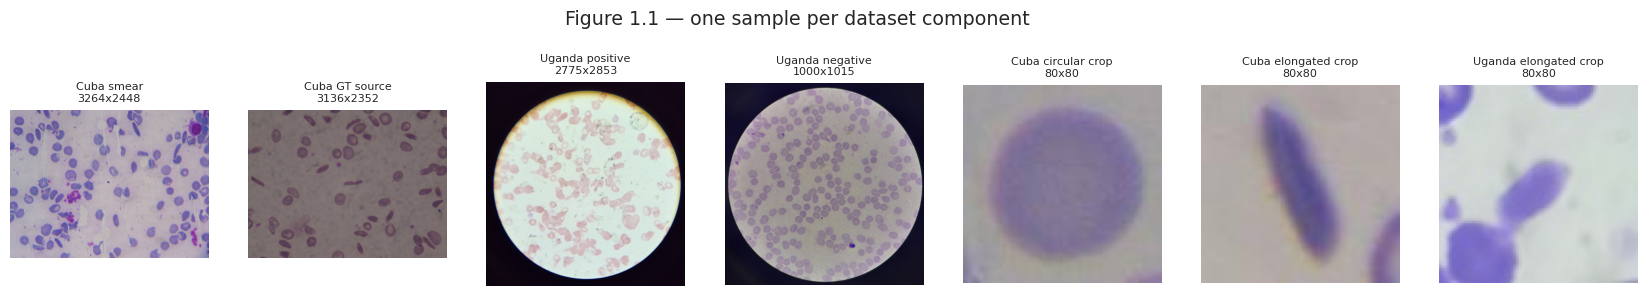

In [3]:
# ── Colab only: mount Drive and unzip. On IBEX the data is already on disk. ──
if PLATFORM == 'colab':
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print('drive already mounted --', e)


_scan_errs = []                                  # unreadable dirs: a silent walk hides the cause


def _parts_map():
    '''the component map scan() fills in -- one key per thing the pipeline needs'''
    return {'gt': [], 'cuba_full': '', 'cuba_circ': '', 'cuba_elong': '',
            'uganda_clean': '', 'uganda_neg': '', 'uga_elong': ''}


def scan(base, max_depth=6):
    '''find each dataset component BY NAME / BY MASK SIGNATURE anywhere under `base`

    followlinks=True on purpose: $HOME is small on IBEX, so the data is usually a symlink
    out to /ibex -- the default walk steps over exactly the link that matters. The realpath
    set is what keeps a self-referential link from walking forever.'''
    parts = _parts_map()
    if not base or not os.path.isdir(base):
        return parts
    seen = set()
    for r, dirs, files in os.walk(base, onerror=_scan_errs.append, followlinks=True):
        real = os.path.realpath(r)
        if real in seen:                             # already been here by another name
            dirs[:] = []
            continue
        seen.add(real)
        dirs[:] = [d for d in dirs if d not in ('__MACOSX', 'drive', 'sample_data', '.git',
                                                'runs_two_stage')]
        if r.count(os.sep) - base.count(os.sep) >= max_depth:
            dirs[:] = []
        low = {f.lower() for f in files}
        if any(f.startswith('mask-circular') for f in low) and \
           any(f.startswith('mask-elongated') for f in low):
            parts['gt'].append(r)
            continue
        name = os.path.basename(r).lower()
        if name == 'positive_sickle_clean':
            parts['uganda_clean'] = r
        elif name == 'negative_normal':
            parts['uganda_neg'] = r
        elif name == 'cells_circular':
            parts['cuba_circ'] = r
        elif name == 'cells_elongated':
            parts['uga_elong' if 'uganda' in r.lower() else 'cuba_elong'] = r
        elif name == 'full_smears' and 'cuba' in r.lower() and imgs_in(r):
            parts['cuba_full'] = r
    return parts


def n_found(p):
    return int(bool(p['gt'])) + sum(1 for k, v in p.items() if k != 'gt' and v)


if CFG['data_root'] and not os.path.isdir(CFG['data_root']):
    print(f"!! data_root does not exist, ignoring it: {CFG['data_root']}\n"
          '   (SCD_DATA_ROOT typo, or the data was never copied to this machine?)')

cands = ([CFG['data_root']] if CFG['data_root'] else []) + CFG['local_hints'] + CFG['drive_hints']
# keep only folders that actually exist, first occurrence wins -- cheap/specific hints come first
bases = [b for i, b in enumerate(cands) if b and os.path.isdir(b) and b not in cands[:i]]
print(f'  {len(bases)} of {len(set(filter(None, cands)))} candidate locations exist on this machine')
parts = _parts_map()
for b in bases:
    f = scan(b)
    print(f'  scanned {b:52s} -> {n_found(f)}/7 components')
    if n_found(f) > n_found(parts):
        parts = f
    if n_found(parts) == 7:
        break

if n_found(parts) < 7:                       # nothing unpacked yet -> find and unzip the archive
    def _is_dataset_zip(z):
        '''does this archive actually hold the components? (reads the index, not the data)'''
        try:
            with zipfile.ZipFile(z) as zf:
                names = '\n'.join(zf.namelist()[:20000]).lower()
        except Exception:
            return False
        return ('cells_circular' in names
                or 'positive_sickle_clean' in names
                or 'mask-circular' in names)

    zips = []
    for h in bases:
        if os.path.isdir(h):
            # name first (fast path), then anything that turns out to hold the components --
            # an upload called archive.zip / Final_Dataset.zip used to be invisible here
            found = sorted(glob.glob(os.path.join(h, '**', '*.zip'), recursive=True))
            zips += [z for z in found if 'ickle' in os.path.basename(z).lower()]
            zips += [z for z in found if z not in zips and _is_dataset_zip(z)]
    if zips:
        dest = '/content' if PLATFORM == 'colab' else os.path.join(CFG['runs_dir'], '..', 'data')
        dest = os.path.abspath(dest)
        os.makedirs(dest, exist_ok=True)
        print(f'\nunzipping {zips[0]} -> {dest}   (a couple of minutes)')
        with zipfile.ZipFile(zips[0]) as zf:
            members = [m for m in zf.namelist()
                       if '__MACOSX' not in m and not os.path.basename(m).startswith('._')]
            zf.extractall(dest, members=members)
        parts = scan(dest)
        print(f'  rescanned {dest} -> {n_found(parts)}/7 components')

gt_dirs = sorted(parts['gt'])
cuba_full, cuba_circ, cuba_elong = parts['cuba_full'], parts['cuba_circ'], parts['cuba_elong']
uganda_clean, uganda_neg, uga_elong = parts['uganda_clean'], parts['uganda_neg'], parts['uga_elong']

manifest = pd.DataFrame([
    ('Cuba  full smears',           cuba_full,          len(imgs_in(cuba_full))),
    ('Cuba  cells_circular',        cuba_circ,          len(imgs_in(cuba_circ))),
    ('Cuba  cells_elongated',       cuba_elong,         len(imgs_in(cuba_elong))),
    ('Cuba  GT mask smears',        '_supplementary/*', len(gt_dirs)),
    ('Uganda positive_sickle_clean', uganda_clean,      len(imgs_in(uganda_clean))),
    ('Uganda negative_normal',      uganda_neg,         len(imgs_in(uganda_neg))),
    ('Uganda cells_elongated',      uga_elong,          len(imgs_in(uga_elong))),
], columns=['component', 'path', 'n'])

missing = manifest[manifest.n == 0]['component'].tolist()
assert not missing, ('\nDataset components NOT FOUND: ' + ', '.join(missing) +
                     '\n  searched: ' + ', '.join(bases) +
                     '\n  found so far:\n' + manifest.to_string(index=False) +
                     ('\n  unreadable dirs while searching: '
                      + '; '.join(f'{type(e).__name__} {e.filename}' for e in _scan_errs[:5])
                      if _scan_errs else '') +
                     "\n  FIX 1: if the data IS on this machine, point at it --"
                     "\n         CFG['data_root'] = '/path/that/holds/Cuba/and/Uganda'"
                     '   (or export SCD_DATA_ROOT=...)'
                     '\n  FIX 2: if it is NOT on this machine yet, copy it up (~332 MB) --'
                     '\n         rsync -a --info=progress2 ~/Downloads/Sickle_Cell_Dataset/ \\'
                     '\n               $USER@ilogin.ibex.kaust.edu.sa:/ibex/user/$USER/Sickle_Cell_Dataset/'
                     '\n         then: export SCD_DATA_ROOT=/ibex/user/$USER/Sickle_Cell_Dataset')

root = os.path.commonpath([p for p in (cuba_full, cuba_circ, cuba_elong, uganda_clean,
                                       uganda_neg, uga_elong) if p] + gt_dirs)
CFG['data_root'] = root
manifest['path'] = manifest['path'].apply(lambda p: os.path.relpath(p, root)
                                          if p.startswith(root) else p)
manifest.to_csv(os.path.join(TAB, 'manifest.csv'), index=False)
print('\ndata_root ->', root)
print('runs_dir  ->', CFG['runs_dir'], '\n')
print(manifest.to_string(index=False))

save_state(data_root=root, cuba_full=cuba_full, cuba_circ=cuba_circ, cuba_elong=cuba_elong,
           uganda_clean=uganda_clean, uganda_neg=uganda_neg, uga_elong=uga_elong, gt_dirs=gt_dirs,
           platform=PLATFORM, tier=TIER, gpu=GPU)

# ── eyeball one example of every component ──
gt_src = [f for f in imgs_in(gt_dirs[0]) if os.path.basename(f).lower().startswith('source')] \
         or imgs_in(gt_dirs[0])
samples = [('Cuba smear', imgs_in(cuba_full)[0]), ('Cuba GT source', gt_src[0]),
           ('Uganda positive', imgs_in(uganda_clean)[0]), ('Uganda negative', imgs_in(uganda_neg)[0]),
           ('Cuba circular crop', imgs_in(cuba_circ)[0]), ('Cuba elongated crop', imgs_in(cuba_elong)[0]),
           ('Uganda elongated crop', imgs_in(uga_elong)[0])]

fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3.2))
for ax, (t, p) in zip(axes, samples):
    im = load_rgb(p)
    ax.imshow(im)
    ax.set_title(f'{t}\n{im.shape[1]}x{im.shape[0]}', fontsize=8)
    ax.axis('off')
fig.suptitle('Figure 1.1 — one sample per dataset component', y=1.04)
savefig(fig, '01_manifest_samples.png')
plt.show()

## 2 — Seed segmentation labels from Cuba's pixel ground truth

The `_supplementary` sets ship a hand-made pixel mask per smear (`mask-circular.jpg`,
`mask-elongated.jpg`). Connected contours in those masks are *real* cell instances, so they become
the trustworthy seed labels — and the **only** data any segmenter is ever graded on.

Two dataset quirks handled here: one `set3` folder has no `source.jpg` (skipped), and `set2`'s masks
are ¼ the resolution of their source — harmless, because YOLO polygons are normalised, so each
contour is normalised by the dimensions of the mask it came from. Both classes collapse to a single
`RBC` class: **stage 1 finds cells, stage 2 names them.**

The cell also measures **how big a real cell actually is** (`A1`/`A50`/`A99` as a fraction of the
frame). Every later blob filter is anchored to that measurement instead of to guessed constants — a
first draft used guessed constants and threw away most of the cells.

  skip (no source image): 11erythrocytesIDB3
GT smears labelled : 78 / 79
GT cell instances  : 2118   (circular 1635 + elongated 483)
cells per smear    : mean 27.2   min 6   max 54
cell area / frame  : p1 0.00153   median 0.00321   p99 0.01771


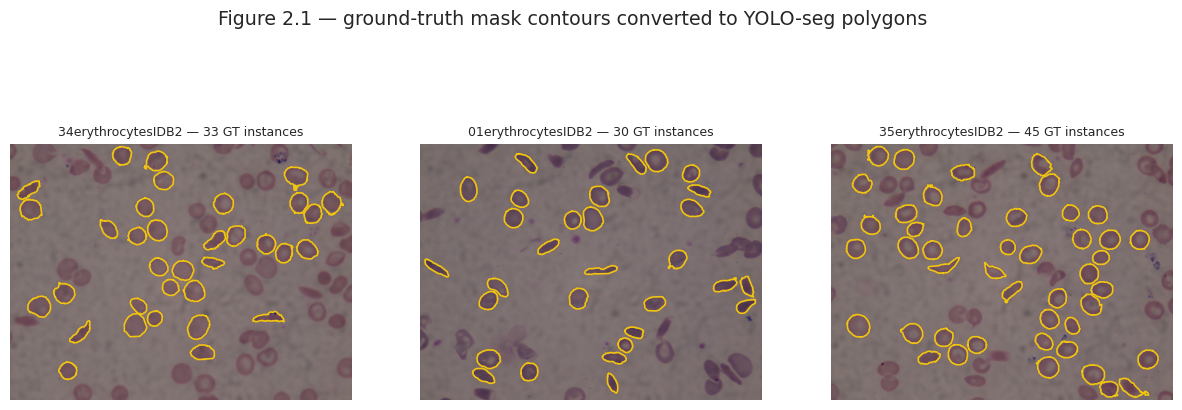

In [4]:
gt_dirs = need('gt_dirs')
GT_DIR = os.path.join(CFG['runs_dir'], 'labels_gt')
os.makedirs(GT_DIR, exist_ok=True)


def find_one(d, stem):
    for f in sorted(os.listdir(d)):
        if f.lower().startswith(stem) and f.lower().endswith(IMG_EXT):
            return os.path.join(d, f)
    return ''


gt_records, n_inst, n_circ, n_elong = [], 0, 0, 0
for d in gt_dirs:
    src = find_one(d, 'source')
    if not src:
        print('  skip (no source image):', os.path.basename(d))
        continue
    polys, per_class = [], {}
    for cls in ('circular', 'elongated'):
        mp = find_one(d, f'mask-{cls}')
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE) if mp else None
        if m is None:
            continue
        p = mask_to_polys((m > 127).astype(np.uint8))     # masks are white-on-black JPEGs
        polys += p
        per_class[cls] = len(p)
    if not polys:
        continue
    txt = os.path.join(GT_DIR, os.path.basename(d) + '.txt')
    with open(txt, 'w') as f:
        for p in polys:
            f.write('0 ' + ' '.join(f'{v:.6f}' for v in p) + '\n')
    gt_records.append({'smear': os.path.basename(d), 'img': src, 'label': txt, 'n': len(polys),
                       'circular': per_class.get('circular', 0),
                       'elongated': per_class.get('elongated', 0)})
    n_inst += len(polys)
    n_circ += per_class.get('circular', 0)
    n_elong += per_class.get('elongated', 0)

gt = pd.DataFrame(gt_records)
gt.to_csv(os.path.join(TAB, 'gt_seed_labels.csv'), index=False)
print(f'GT smears labelled : {len(gt)} / {len(gt_dirs)}')
print(f'GT cell instances  : {n_inst}   (circular {n_circ} + elongated {n_elong})')
print(f'cells per smear    : mean {gt.n.mean():.1f}   min {gt.n.min()}   max {gt.n.max()}')
assert len(gt) >= 50 and n_inst > 500, 'Too few GT instances -- check the mask filenames.'

# ── how big is a real cell? every blob filter downstream is anchored to this ──
gt_area = np.array([cv2.contourArea(np.array(line.split()[1:], np.float32).reshape(-1, 2))
                    for r in gt.itertuples() for line in open(r.label)])
A1, A50, A99 = [float(v) for v in np.percentile(gt_area, [1, 50, 99])]
print(f'cell area / frame  : p1 {A1:.5f}   median {A50:.5f}   p99 {A99:.5f}')
save_state(A1=A1, A50=A50, A99=A99, gt_csv=os.path.join(TAB, 'gt_seed_labels.csv'),
           gt_smears=gt.smear.tolist())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, row in zip(axes, gt.sample(3, random_state=SEED).itertuples()):
    im = load_rgb(row.img)
    H, W = im.shape[:2]
    ax.imshow(im)
    for poly in read_polys(row.label, W, H):
        ax.plot(*np.vstack([poly, poly[:1]]).T, lw=1.2, color='#F1C40F')
    ax.set_title(f'{row.smear} — {row.n} GT instances', fontsize=9)
    ax.axis('off')
fig.suptitle('Figure 2.1 — ground-truth mask contours converted to YOLO-seg polygons', y=1.02)
savefig(fig, '02_gt_polygons.png')
plt.show()

## 3 — Enlarge the training set with SAM pseudo-labels, but *audit* SAM first

80 labelled smears is thin for a detector. SAM auto-masks the unlabelled Cuba and Uganda smears, but
a raw SAM mask set contains everything — background, the field-of-view disc, plasma texture — so a
cell-sized filter (area window, aspect ratio, solidity) is required.

**The filter is not guessed, it is fitted.** Its search range is anchored to the `A1`/`A99` cell
sizes just measured. We auto-mask a subset of the *ground-truth* smears once, sweep candidate filters
against those pixel-perfect masks, and keep the preset with the best mean matched IoU. Only then is
the winner applied to the unlabelled smears, and the achieved IoU + instance recall@0.5 are printed
as the honest quality bound on every SAM-derived label.

> This is SAM used as a **labelling tool**, not as a segmentation competitor. Notebook 02 fine-tunes
> SAM properly and grades it on the same held-out GT smears as YOLO. Ground truth always overrides
> SAM where both exist, and the val split is drawn **by smear**.

In [5]:
if not _has('segment_anything'):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'git+https://github.com/facebookresearch/segment-anything.git'], check=False)
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

A1, A99 = need('A1', 'A99')
SAM_URL = {'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
           'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
           'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'}
SAM_CKPT = os.path.join(WTS, f'sam_{CFG["sam_variant"]}.pth')
if not os.path.exists(SAM_CKPT):
    print(f'downloading SAM {CFG["sam_variant"]} ...')
    torch.hub.download_url_to_file(SAM_URL[CFG['sam_variant']], SAM_CKPT)

sam = sam_model_registry[CFG['sam_variant']](checkpoint=SAM_CKPT).to(DEV).eval()
amg = SamAutomaticMaskGenerator(sam, points_per_side=CFG['sam_points_bulk'],
                                pred_iou_thresh=0.86, stability_score_thresh=0.90,
                                min_mask_region_area=max(30, int(A1 * CFG['sam_side'] ** 2 / 16)))


def keep(m, HW, area_lo, area_hi, ar_max, sol_min):
    '''cell-sized-blob test on one SAM mask dict'''
    A = HW[0] * HW[1]
    if not (area_lo * A <= m['area'] <= area_hi * A):
        return False
    x, y, w, h = m['bbox']
    if w == 0 or h == 0 or max(w / h, h / w) > ar_max:
        return False
    cs, _ = cv2.findContours(m['segmentation'].astype(np.uint8),
                            cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cs:
        return False
    hull = cv2.contourArea(cv2.convexHull(max(cs, key=cv2.contourArea)))
    return hull > 0 and m['area'] / hull >= sol_min      # RBCs are near-convex; debris is not


# ── 1. auto-mask the QC smears ONCE, then sweep filters over the cached masks ──
gt = pd.read_csv(need('gt_csv'))
qc = gt.sample(min(CFG['sam_qc_smears'], len(gt)), random_state=SEED)
qc_cache = []
for row in qc.itertuples():
    im = load_rgb(row.img, CFG['sam_side'])
    H, W = im.shape[:2]
    gt_m = np.zeros((H, W), np.uint8)
    for poly in read_polys(row.label, W, H):
        cv2.fillPoly(gt_m, [poly], 1)
    qc_cache.append((im, gt_m, amg.generate(im)))
print(f'QC auto-masking done on {len(qc_cache)} GT smears')


def score(preset):
    ious, recs = [], []
    for im, gt_m, masks in qc_cache:
        acc = [m['segmentation'] for m in masks if keep(m, im.shape[:2], *preset)]
        n_gt, lbl = cv2.connectedComponents(gt_m)
        if not acc:
            ious.append(0.0)
            recs.append(0.0)
            continue
        u = np.any(acc, axis=0)
        ious.append((u & (gt_m > 0)).sum() / max((u | (gt_m > 0)).sum(), 1))
        hits = tot = 0
        for k in range(1, n_gt):
            g = lbl == k
            if g.sum() < 20:
                continue
            tot += 1
            if max((a & g).sum() / max((a | g).sum(), 1) for a in acc) >= 0.5:
                hits += 1
        recs.append(hits / max(tot, 1))
    return float(np.mean(ious)), float(np.mean(recs))


# anchored to the MEASURED cell size. The widest preset reaches down to A1/8 because Uganda's
# wide-field phone photos show many more, hence relatively smaller, cells.
PRESETS = [(A1 / 2, A99 * 2, 6.0, 0.60), (A1, A99, 5.0, 0.70),
           (A1 / 8, A99 * 4, 8.0, 0.50), (A1 * 2, A99, 4.0, 0.85)]
sweep = pd.DataFrame([dict(zip(['area_lo', 'area_hi', 'ar_max', 'solidity'], p),
                           **dict(zip(['mean_IoU', 'recall@0.5'], score(p)))) for p in PRESETS])
best = PRESETS[int(sweep.mean_IoU.idxmax())]
sam_iou = float(sweep.mean_IoU.max())
sam_rec = float(sweep.loc[sweep.mean_IoU.idxmax(), 'recall@0.5'])
print(sweep.round(5).to_string(index=False))
print(f'\nchosen filter -> area {best[0]:.2e}..{best[1]:.2e} of frame, AR<={best[2]}, '
      f'solidity>={best[3]}')
print(f'SAM label quality vs Cuba GT: mean union-IoU {sam_iou:.3f} | '
      f'instance recall@0.5 {sam_rec:.3f}')
sweep.to_csv(os.path.join(TAB, 'sam_filter_sweep.csv'), index=False)
save_state(sam_preset=list(best), sam_label_iou=sam_iou, sam_label_recall50=sam_rec,
           sam_ckpt=SAM_CKPT)

# ── 2. apply the winning filter to unlabelled smears (rerun-safe: finished images are skipped) ──
SAM_DIR = os.path.join(CFG['runs_dir'], 'labels_sam')
os.makedirs(SAM_DIR, exist_ok=True)
cuba_full, uganda_clean, uganda_neg = need('cuba_full', 'uganda_clean', 'uganda_neg')
todo = ([(p, 'cuba_full') for p in imgs_in(cuba_full)[:CFG['sam_max']['cuba_full']]] +
        [(p, 'uganda_clean') for p in imgs_in(uganda_clean)[:CFG['sam_max']['uganda_clean']]] +
        [(p, 'uganda_neg') for p in imgs_in(uganda_neg)[:CFG['sam_max']['uganda_neg']]])

sam_records = []
for i, (p, src) in enumerate(todo):
    stem = src + '__' + os.path.splitext(os.path.basename(p))[0]
    txt = os.path.join(SAM_DIR, stem + '.txt')
    if not os.path.exists(txt):
        im = load_rgb(p, CFG['sam_side'])
        polys = []
        for m in amg.generate(im):
            if keep(m, im.shape[:2], *best):
                polys += mask_to_polys(m['segmentation'].astype(np.uint8))
        with open(txt, 'w') as f:
            for q in polys:
                f.write('0 ' + ' '.join(f'{v:.6f}' for v in q) + '\n')
    n = sum(1 for _ in open(txt))
    if n:
        sam_records.append({'smear': stem, 'img': p, 'label': txt, 'n': n, 'source': src})
    if (i + 1) % 25 == 0:
        print(f'  SAM pseudo-label {i + 1}/{len(todo)}')

sam_df = pd.DataFrame(sam_records)
print('\nSAM-labelled smears:', len(sam_df), '| instances:', int(sam_df.n.sum()))
print(sam_df.groupby('source').agg(smears=('n', 'size'), instances=('n', 'sum')).to_string())
free_gpu('sam', 'amg')

QC auto-masking done on 30 GT smears
 area_lo  area_hi  ar_max  solidity  mean_IoU  recall@0.5
 0.00076  0.03541     6.0      0.60   0.51093     0.99700
 0.00153  0.01771     5.0      0.70   0.51197     0.96522
 0.00019  0.07083     8.0      0.50   0.50368     1.00000
 0.00305  0.01771     4.0      0.85   0.44511     0.59343

chosen filter -> area 1.53e-03..1.77e-02 of frame, AR<=5.0, solidity>=0.7
SAM label quality vs Cuba GT: mean union-IoU 0.512 | instance recall@0.5 0.965
  SAM pseudo-label 25/260
  SAM pseudo-label 50/260
  SAM pseudo-label 75/260
  SAM pseudo-label 100/260
  SAM pseudo-label 125/260
  SAM pseudo-label 150/260
  SAM pseudo-label 175/260
  SAM pseudo-label 200/260
  SAM pseudo-label 225/260
  SAM pseudo-label 250/260

SAM-labelled smears: 260 | instances: 20227
              smears  instances
source                         
cuba_full         80      11318
uganda_clean      80       4510
uganda_neg       100       4399


## 4 — Assemble the YOLO-format segmentation dataset

Ground truth first, SAM pseudo-labels on top, split **by smear** — never by cell. The one rule that
makes notebooks 01–04 meaningful: **every ground-truth smear that lands in `val` is reserved as
benchmark data**, and no segmenter is ever scored on a SAM-derived label.

In [6]:
YDS = os.path.join(CFG['runs_dir'], 'seg_ds')
for s in ('train', 'val'):
    os.makedirs(os.path.join(YDS, 'images', s), exist_ok=True)
    os.makedirs(os.path.join(YDS, 'labels', s), exist_ok=True)

allrec = gt.assign(source='cuba_gt')[['smear', 'img', 'label', 'n', 'source']].to_dict('records')
allrec += sam_df.to_dict('records')

rng = np.random.default_rng(SEED)
order = rng.permutation(len(allrec))
n_val = int(len(allrec) * CFG['seg_val_frac'])
for j, idx in enumerate(order):
    r = allrec[idx]
    r['split'] = 'val' if j < n_val else 'train'
    dst = os.path.join(YDS, 'images', r['split'], r['smear'] + os.path.splitext(r['img'])[1])
    if not os.path.exists(dst):
        shutil.copy(r['img'], dst)
    shutil.copy(r['label'], os.path.join(YDS, 'labels', r['split'], r['smear'] + '.txt'))

seg_df = pd.DataFrame(allrec)
seg_df.to_csv(os.path.join(TAB, 'seg_dataset.csv'), index=False)
with open(os.path.join(YDS, 'data.yaml'), 'w') as f:
    f.write(f"path: {YDS}\ntrain: images/train\nval: images/val\nnc: 1\nnames: ['RBC']\n")

bench_stems = seg_df[(seg_df.source == 'cuba_gt') & (seg_df.split == 'val')].smear.tolist()
assert bench_stems, 'no GT smear in val -- lower seg_val_frac or re-seed'
save_state(YDS=YDS, seg_csv=os.path.join(TAB, 'seg_dataset.csv'), bench_stems=bench_stems)

print(seg_df.pivot_table(index='source', columns='split', values='n',
                         aggfunc=['size', 'sum']).to_string())
print(f"\nseg dataset: {(seg_df.split == 'train').sum()} train / {(seg_df.split == 'val').sum()} val "
      f"smears | {int(seg_df.n.sum())} instances "
      f"| GT-derived {int(seg_df[seg_df.source == 'cuba_gt'].n.sum())}, "
      f"SAM-derived {int(seg_df[seg_df.source != 'cuba_gt'].n.sum())}")
print(f'benchmark smears (GT masks, held out, used by notebooks 01-04): {len(bench_stems)}')

              size       sum      
split        train val train   val
source                            
cuba_full       66  14  9387  1931
cuba_gt         61  17  1652   466
uganda_clean    67  13  3711   799
uganda_neg      77  23  3448   951

seg dataset: 271 train / 67 val smears | 22345 instances | GT-derived 2118, SAM-derived 20227
benchmark smears (GT masks, held out, used by notebooks 01-04): 17


In [7]:
# ═════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT  ·  identical in every notebook of the series
#
#  Appends one record per run to  runs_two_stage/checkpoints.json  -- the single
#  file that answers "which stages have actually been run, on what hardware, how
#  long did they take, what did they write to disk, and what did they score?".
#  Re-running a stage APPENDS; nothing is overwritten, so the file is the run
#  history of the whole pipeline rather than a snapshot of the last run.
# ═════════════════════════════════════════════════════════════════════════════
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    '''wall-clock minutes this kernel has been alive = how long the run took, near enough'''
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(nb, produced=None, metrics=None, status='ok', notes=''):
    '''record that `nb` finished. `produced` = {label: path}; a falsy path is skipped,
    which is how the optional artefacts (a run dir that was not recreated, a table only
    one branch writes) stay out of the missing list.'''
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb,
           'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'),
           'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'vram_gb': round(VRAM, 1),
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''),
           'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'          # atomic: two stages can finish at once
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print(f'  -> {CKPT_LOG}   ({len(log)} records)')
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<20s} {v}')
    last = {r['nb']: r for r in log}              # one row per stage, most recent run wins
    print(f'\n  stages recorded in this runs_dir ({len(last)}):')
    for k in sorted(last):
        r = last[k]
        print(f'   {"ok" if r["status"] == "ok" else "!!"}  {k:<40s} {r["finished"]}  '
              f'tier {r.get("tier", "?")}')
    return rec

checkpoint(
    '00_setup_and_data',
    produced={'state': STATE_PATH,
              'gt_labels': GT_DIR,
              'sam_labels': SAM_DIR,
              'gt_csv': os.path.join(TAB, 'gt_seed_labels.csv'),
              'seg_csv': os.path.join(TAB, 'seg_dataset.csv'),
              'seg_dataset': YDS},
    metrics={'gt_smears': len(gt), 'gt_instances': n_inst,
             'sam_smears': len(sam_df), 'sam_label_iou': sam_iou,
             'sam_label_recall@50': sam_rec,
             'cell_area_p1': A1, 'cell_area_p50': A50, 'cell_area_p99': A99,
             'train_smears': int((seg_df.split == 'train').sum()),
             'val_smears': int((seg_df.split == 'val').sum()),
             'benchmark_smears': len(bench_stems)},
    notes='every stage below reads this notebook\'s artefacts from disk')


  CHECKPOINT  00_setup_and_data   [ok]   8.1 min
  -> /home/bahajao/runs_two_stage/checkpoints.json   (1 records)
  ok    state                     0.01 MB  /home/bahajao/runs_two_stage/state.json
  ok    gt_labels                 1.21 MB  /home/bahajao/runs_two_stage/labels_gt
  ok    sam_labels                8.19 MB  /home/bahajao/runs_two_stage/labels_sam
  ok    gt_csv                    0.02 MB  /home/bahajao/runs_two_stage/tables/gt_seed_labels.csv
  ok    seg_csv                   0.07 MB  /home/bahajao/runs_two_stage/tables/seg_dataset.csv
  ok    seg_dataset             328.93 MB  /home/bahajao/runs_two_stage/seg_ds
  metric  gt_smears            78.0
  metric  gt_instances         2118.0
  metric  sam_smears           260.0
  metric  sam_label_iou        0.511974
  metric  sam_label_recall@50  0.965222
  metric  cell_area_p1         0.001526
  metric  cell_area_p50        0.003214
  metric  cell_area_p99        0.017707
  metric  train_smears         271.0
  metric  val_sme

{'nb': '00_setup_and_data',
 'status': 'ok',
 'finished': '2026-08-03 09:55:00',
 'minutes': 8.11,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'vram_gb': 79.3,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49919771',
 'runs_dir': '/home/bahajao/runs_two_stage',
 'metrics': {'gt_smears': 78.0,
  'gt_instances': 2118.0,
  'sam_smears': 260.0,
  'sam_label_iou': 0.511974,
  'sam_label_recall@50': 0.965222,
  'cell_area_p1': 0.001526,
  'cell_area_p50': 0.003214,
  'cell_area_p99': 0.017707,
  'train_smears': 271.0,
  'val_smears': 67.0,
  'benchmark_smears': 17.0},
 'artefacts': {'state': {'path': '/home/bahajao/runs_two_stage/state.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.015,
   'modified': '2026-08-03 09:55'},
  'gt_labels': {'path': '/home/bahajao/runs_two_stage/labels_gt',
   'exists': True,
   'kind': 'dir',
   'files': 78,
   'mb': 1.21,
   'modified': '2026-08-03 09:47'},
  'sam_labels': {'path': '/home/bahajao/runs_two_stage/labels_sam'